## Metody obliczania logarytmu naturalnego
Logarytm naturalny oznaczany przez $ln$ czyli $log_\mathrm{e}$. Niezwykle ważna w matematyce funkcja znajdująca zastosowanie w wielu problemach i dziedzinach. $ln$ korzysta z liczby Eulera $\mathrm{e} \approx 2.7182...$, która jest liczbą niewymierną, co dla komputera stwarza trudności, jakich nie ma "na kartce", jako że reprezentacja liczb w komputerze ma swoje ograniczenia.

W tym opracowaniu pokaże jakie są metody liczenia $ln$, porównam je między sobą i opisze zasosowania.

#### Szereg Taylora
Jeżeli funkcja $f(x)$ ma n-tą pochodną $f^{(n)}(x)$ w pewnym przedziale domkniętym zawierającym punkt $a$, wtedy dla każdego $x$ z tego przedziału ma miejsce następujący wzór Taylora:

$$
f(x)=f(a)+\frac{f'(a)}{1!}(x-a)+\frac{f''(a)}{2!}(x-a)^2+...+\frac{f^{(n)}(c_n)}{n!}(x-a)^n,
$$

Podany wzór możemy zapisać w postaci szeregu potęgowego:
$$
f(x)=\sum\limits_{n=0}^{\infty}\frac{f^{(n)}(a)}{n!}(x-a)^{n}
$$
Ponieżej implementacja danego wzoru dla $f(x) = ln(x)$. Dana funkcja stanowi bardzo uproszczoną i niepraktyczną werjsę do oblicznia $ln(x)$ szeregiem Taylora. Przykład jest czysto obrazowy. W dalszej części zaprezentuję lepszą, optymalną werjsę, która jest zbilżona do tej używanej w biblitekach. 
Problemem poniższej funkcji jest choćby sposób wyznaczania punktu roziwnięcia. Dla uproszczenia zakłada, że punktem rozinięca jest wartość całkowita $a = x + 1$, co zapewnia zbieżnośc i jest poprawne, jednak nieoptymalne z punktu widzenia numerycznego. Dla niektórych przypadków wyznaczone $a$ spowoduje, że szereg będzie bardzo wolno zbieżny i otzymanie dokładnego wyniku może okazać się niemożliwe. Dodatkowow pomija jest wielką zaletę szeregu Taylora jaką jest możliwość obliczania z dowolną precyzją, o tym dalej.

Dla referencji zaimplementowałem również metodę Newtona-Raphsona(styczne), którą też da się zastosować do obliczania lognarytmu naturalnego Jednak nie będę poświęcaj jej dużo miejsca, jako że w opisałem ją poprzednim  opracowaniu. Tutaj pojawia się jedynie element do porównania dla innych metod w kateoriach precyzji i szybkości działania.
 


In [1]:
import math
import numpy as np
from sympy import symbols, diff, lambdify, log

def taylor_series(value, n):
    
    # Obsługa przypadków specjalnych
    
    if value < 0:
        raise ValueError("Nie można obliczyć ln z x < 0!")
    if value == 0:
        return -math.inf, 0
    if value == 1:
        return 0, 0
    
    
    # wyznaczanmy punktu pochodnej
    
    a = int(math.ceil(value))
    x = symbols('x')
    f = log(x)
    
    # zapisujemy kolejne wyrazy szeregu aż do n-tego
    taylor_poly = 0
    for i in range(n+1):
        
        deriv_f = diff(f, x, i)                                         # wyznaczamy pochodną n-tego stopnia z ln(x)
        deriv_at_a = deriv_f.subs(x, a)                                 # wartość pochodnej w punkcie a
        term = (deriv_at_a / math.factorial(i)) * (x - a) ** i          # wyznaczamy n-ty wzór n-tego wyarzu szeregu
        taylor_poly += term                                             # dodajemy utworzony wyraz do szeregu
    
    taylor_fun = lambdify(x, taylor_poly, modules=['math'])             
    approx = taylor_fun(value)                                          # obliczamy sumę 
    return approx, taylor_poly                                          # zwracamy przybliżenie i szereg

def newton_raphson(x, epsilon):
    max_iter = 1000
    if x < 0:
        raise ValueError("Nie można policzyć ln z liczby mniejszej niż 0!")
    if x == 1:
        return 0
    if x == 0:
        return -math.inf
    m, e = math.frexp(x)
    M = m * 2.0
    k = e - 1
    y = 0.0
    for _ in range(max_iter):
        ey = math.exp(y)
        f_val = ey - M
        if abs(f_val) < epsilon:
            break
        y = y - f_val / ey
    ln2 = math.log(2)
    result = y + k * ln2
    return result

In [4]:
x = 5
n = 20
approx, wzor = taylor_series(x , n)
print(f'Przybliżenie {n}-tego stopnia wartości {x}: {approx}')
print('Wynik z biblioteki math: ', math.log(x))
print(f'Otrzymany wzór: {wzor}')

Przybliżenie 20-tego stopnia wartości 5: 1.6094379124341003
Wynik z biblioteki math:  1.6094379124341003
Otrzymany wzór: x/5 - (x - 5)**20/1907348632812500 + (x - 5)**19/362396240234375 - (x - 5)**18/68664550781250 + (x - 5)**17/12969970703125 - (x - 5)**16/2441406250000 + (x - 5)**15/457763671875 - (x - 5)**14/85449218750 + (x - 5)**13/15869140625 - (x - 5)**12/2929687500 + (x - 5)**11/537109375 - (x - 5)**10/97656250 + (x - 5)**9/17578125 - (x - 5)**8/3125000 + (x - 5)**7/546875 - (x - 5)**6/93750 + (x - 5)**5/15625 - (x - 5)**4/2500 + (x - 5)**3/375 - (x - 5)**2/50 - 1 + log(5)


Jak widać działa i udało się obliczyć przybliżoną wartość. Jednak w obecnie formie musimy podać stopień rozwinięcia, a przecież szereg Taylora pozwala liczyć do ustalonej przecyzji, zatem taki sposób, jest niepraktyczny. Przykład, kiedy taka mocno uproszczona wersja nie działa ...


In [7]:
x = 0.0004252
n = 10
while n <= 100:
    n += 10
    approx, wzor = taylor_series(x, n)
    print(approx)
print(f'Dokładne przyblizenie: {math.log(x)}')

-3.589252803499891
-3.982270350028925
-4.2616052965750875
-4.478055574923696
-4.6545175436551425
-4.803289672412774
-4.931746842642392
-5.044661655286998
-5.145300873687281
-5.235999047895837
Dokładne przyblizenie: -7.762950911496481


Jak widać zbieżność jest, ale potwornie wolna...

### Obliczanie wartości z dowolną precyzją przy pomocy szeregu Taylora
Pisząc z dowolną precyzją mam oczywiście na myśli obliczenia "na kartce", ponieważ w komputerze mamy skończone zasoby, a co za tym idzie ograniczone możliwości reprezentacji liczb.
#### Reszta Lagrange'a, czyli nasz błąd
Ostatni wyraz szeregu Taloyra oznacza się jako $R_n = \frac{f^{(n)}(c_n)}{n!}(x-a)^n$ i to jest właśnie wartość naszego błędu. Dlatego zamiast podawać liczbę wyrazów do zsumowania, wystarczy podać pożdaną precyzję $\epsilon$. Wtedy licząc sprawdzamy wartość ostatniego wyrazu dla naszego x i porównujemy z $\epsilon$. Stąd mamy dokładność:
$$
 |R_n|=|\frac{f^{(n)}(c_n)}{n!}(x-a)^n|<\epsilon,
$$

W kodzie będziemy zwyczajnie liczyć wartość otatniego, czyli obecnego wyrazu pętli i porównywać z podanym $\epsilon$. Jednak nie powinien to być jedyny warunek zaprzestania obliczeń, jako że może się zdarzyć sytuacja, w której szczególnie, jeśli mamy bardzo dokładną reprezntację liczby np. 128 bitów, kiedy będzie konieczne wykonanie bardzo dużej liczby iteracji, przed otrzymaniem porządanej precyzji. Dlatego warto ustawić warunek zabezpieczający przed takim przypadkiem w postaci maksymalnej liczby iteracji.

#### Wyznaczanie punktu rozwinięcia
Jak wspomniałem wcześniej są lepsze, uniwersalne sposoby wyznaczania punktu rozwinięcia. Głównym czynnikiem tempa zbiegania szeregu Taylora jest nie sama wartość $a$, lecz jej odległość od x. Składową każdego wyrazu szeregu jest wyrażenie: $(x - a)^n$, które przemnażamy przez $\frac{f^{(n)}(a)}{n!}$. Stąd im różnica $x - a$ jest mniejsza, tym kolejne wyrazy szeregu maleją szybciej, a co za tym idzie zbliżamy się do relanej wartości. Chociaż tutaj znowu pojawia się problem ewentualnych błędów zaokrąglenia, jeśli tak wyznaczony składnik byłyby odpowienio mały.

Kolejną kwetią jest odpowienie dobranie punktu $a$. Spójrzmy na kolejne pochodne $\ln(x)$ $n$-tego stopnia w punkcie $a$ dla $n = 1,2,3,4,5$:

$$
f'(a) \;=\; \frac{1}{a},
$$
$$
f''(a) \;=\; -\,\frac{1}{a^{2}},
$$
$$
f^{(3)}(a) \;=\; \frac{2}{a^{3}},
$$
$$
f^{(4)}(a) \;=\; -\,\frac{6}{a^{4}},
$$
$$
f^{(5)}(a) \;=\; \frac{24}{a^{5}}.
$$
Dzielmy przez $a^n$ - źle ustalone $a$ szybko doprowadziłoby do dzielenia licznika przez ogormne wartości, a co za tym idzie do utraty precyzji i błędów.

#### Roziwązanie - redukcja arguemntu
Żeby móc zredukować argument najpierw musimy mieć pewność, że zrobimy to odpowiednio - nie przełoży się to na błędne obliczenia. Jak to się dzieje?

Liczby zmiennoprzecinkowe w formacie IEEE 754 Double są reprezentowane na 64 bitach, w których zawiera się: bit znaku, mantysa - 52 bity i wykładnik - 11 bitów.
Mansya = 1.0 + 0.'ciąg bitów matysy'
Całą liczbę x przedstawiamy w postaci z odpowienim znakiem:
$$
x = 2^k * m
$$
W celu przeprowadzenia redukcji korzystamu z faktu:
$$
\ln(x) = \ln(m) + k\ln(2)
$$
#### Co dzięki temu zyksujemy?
1. Z poniżej własności wynika, że nasze obliczenia możemy przeprowadzać jedynie na mantysie liczby i na końcu dodać wartość $k\ln(2)$. Dzięki temu możemy dokonać redukcji argumentu poprzez sprowadzenie mantysy do pewnego zakresu.
    Sposób z implementacji funkcji $\ln(x)$ z biblioteki C Sun Microsystems: sprowadzamy mantysę do zakresu $[\frac{2}{\sqrt{2}}; \sqrt{2}]$ jednocześnie odpowiendnio skalując wykładnik, żeby zachować faktyczną liczbę.
2. Dzięki temu, że sprowadziliśmy nasz argument, a właściwie mantysę, do stałego przedzialu możemy wyznaczyć stały punkt rozwinięcia, w którym będzie: $a = 1$. Dzięki temu nie musimy zgadywać dobrego punktu rozwinięcia, tylko mamy taki, w który:

    a)Pozwala łatwo policzyć wartość pochodnej i mamy grawancę jej istnienia
    
    b)Odpowiednio blisko $x$ w celu zapewnienia odpowiedniego tempa zbieżności.
    
    Skoro nasze $x$(mantysa) zostało sprowadzone do przedziału $[\frac{1}{\sqrt{2}}; \sqrt{2}]$ oraz punkt roziwniecią jest stały: $a = 1$, to wyrażenie  $(x - a)$ mieści się w przedziale $\approx [-0.2929; 0.4114]$. Dzięki temu podnoszą do potęgi kolejne wyrażenia szybko zbiegamy do 0, czyli przyspieszamy zbieżność całego szeregu.
    
3. Obliczenia przeprowadzamy jedynie na mantysie a wynik końcowy poprawiamy o dodanie $k\ln(2)$. Przy czym $\ln(2)$ mamy zapisaną jako stałą zmienną w funkcji, więc nie ma potrzeby obliczania w trakcie, co zresztą byłoby "trudne" w funkcji liczącej $\ln(x)$ ...

    W funkcji z biblioteki C $\ln(2)$ przechowuje się jako dwie osobne zmienne:
    
    a) $\ln(2)_{hi} = 6.93147180369123816490e-01$
      
    b) $\ln(2)_{lo} = 1.90821492927058770002e-10$,

    których suma daje bardzo dokładną wartość $\ln(2)$.
    
Przejdźmy teraz od implementacji i porównań

In [8]:
def taylor_optimized_eps(value, eps, max_iter = 10000):
    if value < 0:                               # obsługa wartości skrajnych
        raise ValueError("Nie można obliczyć ln(x) dla x < 0!")
    if value == 0:
        return -math.inf, 0
    if value == 1:
        return 0.0, 0
    
    mant, exp = math.frexp(value)                # wydobycie mantysy i wykładnika

    if mant < math.sqrt(0.5):                    # sprowadzenie mantysy do odpowiedniego zakresu i korekcja wykładnika
        mant *= 2.0                             
        exp -= 1

    k = exp
    m = mant
    x = symbols('x')
    
    f_sym = log(x)           
    taylor_poly = 0
    last_term_value = None
    i = 0
    
    
    while i <= max_iter:                         # warunek stopu po przekroczeniu maksymalnej liczby iteracji
        deriv_f = diff(f_sym, x, i)          
        deriv_at_1 = deriv_f.subs(x, 1)      
        coef = deriv_at_1 / math.factorial(i)
        term = coef * (x - 1) ** i
        term_i_value = abs(term.subs(x, m))
        taylor_poly += term
        
        if term_i_value < eps and i > 0:        # wychodzimy z pętli po uzyskami porządanej precyzji
            break
            
        i += 1
                                                # stałe dokladnie przybliżające ln(2)
    ln2_hi = 6.93147180369123816490e-01
    ln2_lo = 1.90821492927058770002e-10   

    taylor_fun = lambdify(x, taylor_poly, modules=['math']) 
    approx_ln_m = taylor_fun(m)                            # wyliczamy sumę
    approx_ln_x = approx_ln_m + k * ln2_hi + k * ln2_lo    # odpowiednio ją korygujemy

    return approx_ln_x, taylor_poly, i

In [9]:
x2 = 10
eps = 0.1e-15
approx1, wzor1, iteracje = taylor_optimized_eps(x2, eps)
print(f"Przybliżenie: {approx1:.15f}")
print(f'Otrzymany szereg: {wzor1}')
print(f"Liczba iteracji(zsumowanych wyrazów): {iteracje}")

Przybliżenie: 2.302585092994045
Otrzymany szereg: x + (x - 1)**25/25 - (x - 1)**24/24 + (x - 1)**23/23 - (x - 1)**22/22 + (x - 1)**21/21 - (x - 1)**20/20 + (x - 1)**19/19 - (x - 1)**18/18 + (x - 1)**17/17 - (x - 1)**16/16 + (x - 1)**15/15 - (x - 1)**14/14 + (x - 1)**13/13 - (x - 1)**12/12 + (x - 1)**11/11 - (x - 1)**10/10 + (x - 1)**9/9 - (x - 1)**8/8 + (x - 1)**7/7 - (x - 1)**6/6 + (x - 1)**5/5 - (x - 1)**4/4 + (x - 1)**3/3 - (x - 1)**2/2 - 1
Liczba iteracji(zsumowanych wyrazów): 25


#### Porównanie
Zobaczmy teraz, co dały nam te zmiany. Porównamy średni błąd dla pewnego zestawu liczb oraz czasy wykonywania. Zobaczmy przypadek, w którym pierwszy spsób był bardzo słaby: $x = 0.0004252$

In [11]:

approx2, wzor2, iteracje = taylor_optimized_eps(x, eps)
print("PRzybliżenie szeregiem Taylora:", approx2)
print("Biblioteka math:",math.log(x))
print(f"Liczba iteracji(zsumowanych wyrazów): {iteracje}")

PRzybliżenie szeregiem Taylora: -7.762950911496481
Biblioteka math: -7.762950911496481
Liczba iteracji(zsumowanych wyrazów): 17



I proszę, udało się obliczyć precyzyjnie obliczyć przybliżenie (na tyle na ile pozwala IEEE 754 Double) $\ln(x), x = 0.0004252$ i to w relatywnie niewielkiej liczbie 17 iteracji.

### Rozwiązanie biblioteki math z C
Jednak pomimo wszytskich zalet szeregu Taylora nie jest wykorzystywany implementacji bibliotek matematycznych. Biblioteka math w C korzysta z metody Remeza. Nie mam zamiaru jej tutaj dokładnie opiswywać, ponieważ opracowanie dotyczy głównie szeregu Taylora. Optymalizacje z rozwiązania w C zaimplementowałem w funkcji taylor_optimized_eps - redukcja argumentu oraz 

#### Czym jest metoda Remeza i porówanie z szergiem Taylora

Metoda Remeza polega na znalezieniu wielomianu, który minimalizuje maksymalny błąd aproksymacji danej funkcji na określonym przedziale, tak aby odchyłki oscylowały równomiernie wokół zera. W przeciwieństwie do rozwinięcia Taylora, które dopasowuje kolejne pochodne w jednym punkcie (zyskując bardzo dobrą zgodność lokalną), Remez dba o to, by błąd był jak najmniejszy na całym wybranym przedziale. Obie metody dają wielomiany przybliżające funkcję, ale Taylor gwarantuje dokładność w pobliżu punktu rozwinięcia, a Remez rozkłada błąd jednolicie w całym zakresie. Dzięki temu wielomian Remeza jest zwykle krótszy (ma niższy stopień) niż Taylor, by osiągnąć podobną dokładność na szerszym przedziale. Poniżej implementacja.

In [92]:
Lg1 = 0.666666666666735130e+00
Lg2 = 0.3999999999940941908e+00
Lg3 = 0.2857142874366239149e+00
Lg4 = 0.2222219843214978396e+00 
Lg5 = 0.1818357216161805012e+00
Lg6 = 0.1531383769920937332e+00
Lg7 = 0.1479819860511658591e+00

ln2_hi = 6.93147180369123816490e-01
ln2_lo = 1.90821492927058770002e-10

def ln1p_remez(f):
    s = f / (2.0 + f)
    s2 = s * s
    w = s2 * s2
    t = s2 * (Lg1 + s2 * (Lg2 + s2 * (Lg3 + s2 * (Lg4 + 
            s2 * (Lg5 + s2 * (Lg6 + s2 * Lg7))))))
    hfsq = 0.5 * f * f
    return f - (hfsq - s * (hfsq + t))


def remez(value):
    if value < 0:
        raise ValueError("Nie można obliczyć ln(x) dla x < 0!")
    if value == 0:
        return -math.inf
    if value == 1:
        return 0.0

    mant, exp = math.frexp(value)
    if mant < math.sqrt(0.5):
        mant *= 2.0
        exp -= 1
    k = exp
    m = mant
    f = m - 1.0

    approx_ln_m = ln1p_remez(f)
    approx_ln_x = approx_ln_m + (k * ln2_hi) + (k * ln2_lo)

    return approx_ln_x

Jako ciekawostkę dodam, że wartość $\ln(0)$ jest inaczej obsługiwana przez bibliotekę pythona math i implementację Sun Microsystems w C. W biblitece C dla 0 zwaracana wartość to $-\infty$, z kolei math zwaraca nam błąd dziedziny.

W swoich implementacjach zdecydowałem się na wybór z C - zwracania $-\infty$ dla $x = 0$

In [12]:
print(math.log(0))

ValueError: math domain error

### Porównania i testy
Podstawą testów będzie czas wykonywania mierzony dla zestawu testowego. Oprócz tego sprawdzimy średni błąd obliczeń względem math.log


8.889904711395502e-05
0.0005268129170872271
0.0004222739371471107


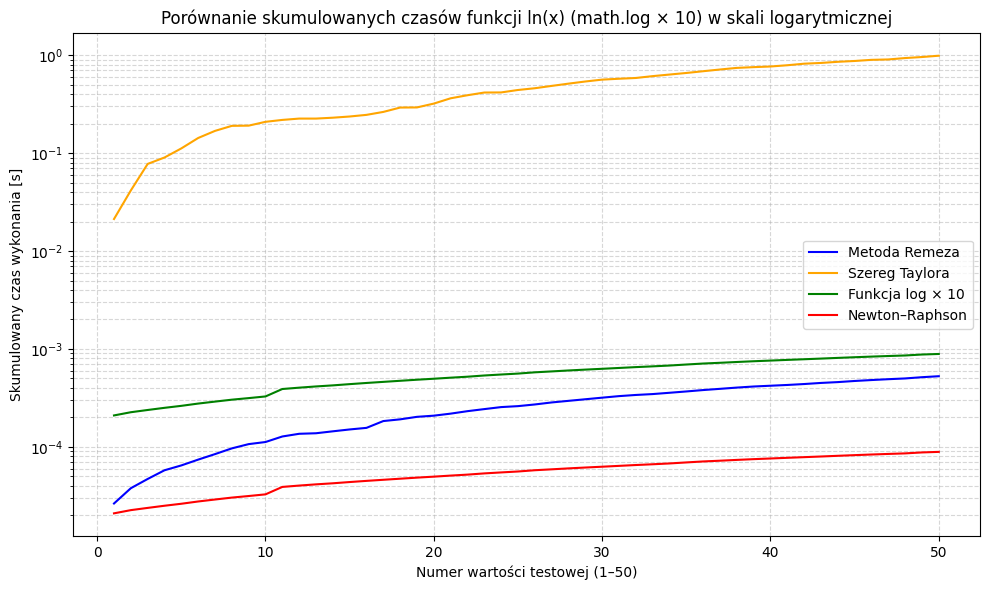

In [251]:
import time
import pandas as pd
import matplotlib.pyplot as plt

eps = 0.1e-15

czas_remez = []
czas_taylor = []
czas_math_log = []
czas_newton = []

dif_taylor = []
dif_remez = []
dif_newton = []

sum_taylor = 0.0
sum_remez = 0.0
sum_math = 0.0
sum_newton = 0.0

test_values = [
  1e-12,  1e-10,  1e-8,   1e-6,   1e-4,
  1e-2,   1e-1,   0.2,    0.5,    0.9,
  0.99,   0.999,  1.0,    1.0001, 1.001,
  1.01,   1.1,    1.5,    2.0,    2.5,
  2.71828,3.0,    3.14159,4.0,    5.0,
  7.0,    10.0,   20.0,   50.0,   100.0,
  1e3,    2e3,    5e3,    1e4,    2e4,
  5e4,    1e5,    2e5,    5e5,    1e6,
  1e7,    1e8,    1e9,    1e10,   1e12,
  3.1415926535e5, 6.022e23, 9.109e-31, 2.99792458e8, 1.602176634e-19
]
for x in test_values:
    t0 = time.perf_counter()
    log_math = np.float128(math.log(x))
    t1 = time.perf_counter()
    sum_math += (t1 - t0)
    czas_math_log.append(sum_math)
    
    
    t0 = time.perf_counter()
    log_remez = np.float128(remez(x))
    t1 = time.perf_counter()
    dif = abs(log_math - log_remez)
    dif_remez.append(dif)
    sum_remez += (t1 - t0)
    czas_remez.append(sum_remez)
    
    t0 = time.perf_counter()
    taylor = taylor_optimized_eps(x, eps)
    log_taylor = np.float128(taylor[0])
    
    t1 = time.perf_counter()
    log_taylor = np.float128(log_taylor)
    dif = abs(log_math - log_taylor)
    dif_taylor.append(dif)
    sum_taylor += (t1 - t0)
    czas_taylor.append(sum_taylor)
    
    
    
    t0 = time.perf_counter()
    log_newton = np.float128(newton_raphson(x, eps))
    t1 = time.perf_counter()
    dif = abs(log_math - log_newton)
    dif_newton.append(dif)
    sum_newton += (t1 - t0)
    czas_newton.append(sum_math)

print(sum_math)
print(sum_remez)
print(sum_newton)

x_axis = list(range(1, len(test_values) + 1))

# Na osi log, przeskalujemy math.log * 10:
przeskalowany_czas_math = [c * 10 for c in czas_math_log]

plt.figure(figsize=(10, 6))
plt.plot(x_axis, czas_remez,         label='Metoda Remeza',    color='blue')
plt.plot(x_axis, czas_taylor,        label='Szereg Taylora',   color='orange')
plt.plot(x_axis, przeskalowany_czas_math, label='Funkcja log × 10', color='green')
plt.plot(x_axis, czas_newton,        label='Newton–Raphson',   color='red')

plt.xlabel('Numer wartości testowej (1–50)')
plt.ylabel('Skumulowany czas wykonania [s]')
plt.title('Porównanie skumulowanych czasów funkcji ln(x) (math.log × 10) w skali logarytmicznej')

plt.yscale('log')
plt.grid(which='both', linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

### Porównanie czasów

Oczywiście najwydajniesza jest funckja log z biblioteki math. Oczywiście wynika to głownie z faktu, że faktyczny kod obliczeniowy jest wykonywany w C, który jest wielokrotnie szybszym niż python językiem, to jednak zabiegi optymalizacyjne różnież pełnią tutaj rolę. Wykres wartości funkcji log został przekskalowany x 10, inaczej wartości były tak małe, że ciężko było zmieścić wszystkie wykresy na jednej osi.

Niestety szereg Taylora radzi sobie najgorzej. Głównym powodem jest fakt, że obliczając kolejene przybliżenia wyznaczamy kolejene wyrazy dużo iteracji. W porówaniu do metody Remeza, która zamiast budować wyrazy szeregu, to stosuje gotowe przybliżenie wielomianowe, które przekłada się na znacznie szybsze obliczenia.

Dodatkwow dla porówania metoda Newtona-Raphsona, która również jest bardzo szybka, ze względu na swoją specyfikcę zbieżności.

### Porówanie średniego błędóu
Dla dopełnienia sprawdźmy średnie błędy obliczeniowe metod względem funkcji biblioteki math. Poniżej wyniki.

In [255]:
err_taylor = sum(dif_taylor) / len(dif_taylor)
err_remez = sum(dif_remez) / len(dif_remez)
err_newton = sum(dif_newton) / len(dif_newton)

print("Średnie błędy")
print(f"Remez: {err_remez}")
print(f"Taylor: {err_taylor}")
print(f"Newton-Raphson: {err_newton}")




Średnie błędy
Remez: 5.977163208825687e-16
Taylor: 4.524321455673386e-16
Newton-Raphson: 6.875733706349085e-16


Jak możemy zauważyć choć róznice są, to niewielkie. Błąd każdej z metod jest rzędu piętnastego miejsca po przecinku, co jest w limicie mozliwości typu IEEE 754 Double. Tak więc każda z tych metod oferuje dość dobrą dokładność oczywiście z pewnymi niuansami, jak to, że w metodzie Newotna-Raphsona nie jesteśmy tak dokładnie kontorlować dokładności jak w szeregu Taylora czy metodzie Remeza.

## Zastosowania
Na koniec krótko o zastosowaniach, gdzie wykorzustuje się obliczanie $\ln(x)$ i precyzja obliczeń ma znaczenie. Ponieżej opisane dwa przykłady.

### 1. Obliczanie entropii w teorii informacji
W systemach kompresji danych i kryptografii entropia Shannona jest definiowana jako  
$$
H = -\sum_{i} p_i \ln p_i,
$$  
gdzie $p_i$ to prawdopodobieństwo wystąpienia $i$-tego symbolu. Jeśli wartości $p_i$ są bardzo małe (np. przy rzadkich symbolach w dużej alfabecie), to $\ln p_i$ będzie ujemne i o dużej bezwzględnej wartości; mała niedokładność w obliczeniu $\ln p_i$ może więc istotnie zniekształcić wynik sumaryczny entropii. Dokładne wyznaczenie $\ln p_i$ jest też kluczowe, gdy potrzebujemy precyzyjnie oszacować zysk kompresji lub wyznaczyć granice kryptograficzne. Dlatego w praktyce stosuje się funkcje logarytmiczne o wysokiej precyzji, by uniknąć błędów zaokrągleń, które w ostatecznej sumie mogłyby dać niepoprawne wyniki i wpłynąć na bezpieczeństwo czy efektywność algorytmu.

### 2. Wyznaczanie log-wiarygodności w modelach probabilistycznych
W statystycznych modelach uczenia maszynowego (np. regresja logistyczna czy ukryte modele Markowa) przy obliczaniu funkcji wiarygodności dla bardzo małych prawdopodobieństw wygodniej jest pracować na skali logarytmicznej:  
$$
\ln L = \sum_{i} \ln p(x_i \mid \theta).
$$  
Gdy $p(x_i \mid \theta$ może być rzędu $10^{-20}$ lub mniejszych, bezpośrednie mnożenie małych liczb szybko prowadzi do podziału przez zero (underflow), a błędy numeryczne kumulują się. Użycie $\ln$ pozwala sumować wartości zamiast mnożyć, ale wymaga, aby logarytm był wyliczony z wysoką precyzją – inaczej błąd w pojedynczym $\ln p(x_i)$ może przełożyć się na zupełnie inny wynik końcowy przy optymalizacji parametrów $\theta$. Dlatego w bibliotece numerycznej często stosuje się specjalne implementacje $\ln$, które gwarantują stabilne i precyzyjne wartości nawet dla skrajnie małych argumentów.  


### Źródła
https://www.netlib.org/fdlibm/

https://en.wikipedia.org/wiki/Natural_logarithm

Wykłady z Analizy matematycznej 1 - prof. UAM dr hab. Mieczysław Cichoń
